# Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import joblib
import seaborn as sns
import matplotlib.pyplot as plt

## Load Dataset

In [2]:
file_path = "student_data.csv" 
df = pd.read_csv(file_path)
print("Data Loaded Successfully") 

Data Loaded Successfully


# Data Preprocessing

### Drop 'Student ID' as it's not a useful feature


In [3]:
df.drop('Student ID', axis=1, inplace=True)
df = df.dropna(subset=['Passed'])

In [4]:
df

,Study Hours per Week,Attendance Rate,Previous Grades,Participation in Extracurricular Activities,Parent Education Level,Passed
0,12.5,NaN,75.0,Yes,Master,Yes
1,9.3,95.3,60.6,No,High School,No
2,13.2,NaN,64.0,No,Associate,No
3,17.6,76.8,62.4,Yes,Bachelor,No
4,8.8,89.3,72.7,No,Master,No
...,...,...,...,...,...,...
39995,15.6,93.8,51.4,Yes,Master,No
39996,11.3,66.4,64.2,No,Doctorate,Yes
39997,13.1,65.6,38.1,No,Bachelor,No
39998,14.1,74.9,NaN,Yes,Master,No


## Handle missing values (fill attendance with median)

In [5]:
df['Attendance Rate'].fillna(df['Attendance Rate'].median(), inplace=True)

/var/folders/hg/z7q2gy4s2l13r1z9ly4_j6ym0000gn/T/ipykernel_5944/3634000251.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Attendance Rate'].fillna(df['Attendance Rate'].median(), inplace=True)


##  Encode categorical variables

In [6]:
df['Participation in Extracurricular Activities'] = df['Participation in Extracurricular Activities'].map({'Yes': 1, 'No': 0})
df = pd.get_dummies(df, columns=['Parent Education Level'], drop_first=True)


In [7]:
df['Passed'] = df['Passed'].map({'Yes': 1, 'No': 0})

In [8]:
assert df.drop('Passed', axis=1).select_dtypes(include='object').empty, "Non-numeric columns still exist"

In [9]:
df

,Study Hours per Week,Attendance Rate,Previous Grades,Participation in Extracurricular Activities,Passed,Parent Education Level_Bachelor,Parent Education Level_Doctorate,Parent Education Level_High School,Parent Education Level_Master
0,12.5,75.2,75.0,1.0,1,False,False,False,True
1,9.3,95.3,60.6,0.0,0,False,False,True,False
2,13.2,75.2,64.0,0.0,0,False,False,False,False
3,17.6,76.8,62.4,1.0,0,True,False,False,False
4,8.8,89.3,72.7,0.0,0,False,False,False,True
...,...,...,...,...,...,...,...,...,...
39995,15.6,93.8,51.4,1.0,0,False,False,False,True
39996,11.3,66.4,64.2,0.0,1,False,True,False,False
39997,13.1,65.6,38.1,0.0,0,True,False,False,False
39998,14.1,74.9,NaN,1.0,0,False,False,False,True


## Define features and target

In [10]:
X = df.drop('Passed', axis=1)
y = df['Passed']

# Train-Test Split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Model

In [12]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

# Evaluate Model

In [13]:
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.5035526315789474
              precision    recall  f1-score   support

           0       0.51      0.51      0.51      3839
           1       0.50      0.50      0.50      3761

    accuracy                           0.50      7600
   macro avg       0.50      0.50      0.50      7600
weighted avg       0.50      0.50      0.50      7600



# Save Model

In [14]:
joblib.dump(model, 'student_performance_model.pkl')
print("Model saved as student_performance_model.pkl")

Model saved as student_performance_model.pkl


# Feature Importance

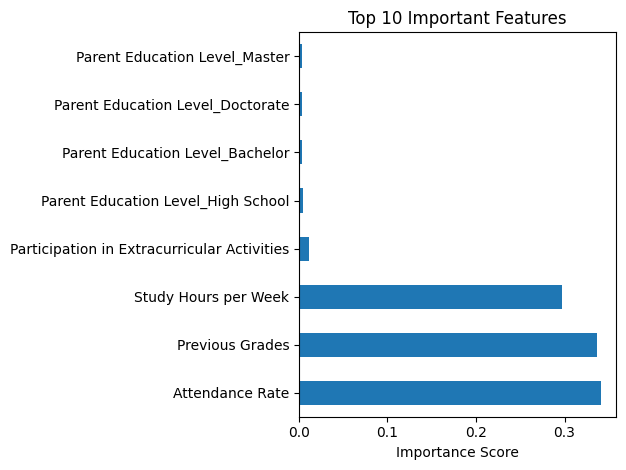

In [15]:
feature_importances = pd.Series(model.feature_importances_, index=X.columns)
feature_importances.nlargest(10).plot(kind='barh')
plt.title("Top 10 Important Features")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()


In [80]:
df

,Study Hours per Week,Attendance Rate,Previous Grades,Participation in Extracurricular Activities,Passed,Parent Education Level_Bachelor,Parent Education Level_Doctorate,Parent Education Level_High School,Parent Education Level_Master
0,12.5,75.2,75.0,1.0,1,False,False,False,True
1,9.3,95.3,60.6,0.0,0,False,False,True,False
2,13.2,75.2,64.0,0.0,0,False,False,False,False
3,17.6,76.8,62.4,1.0,0,True,False,False,False
4,8.8,89.3,72.7,0.0,0,False,False,False,True
...,...,...,...,...,...,...,...,...,...
39995,15.6,93.8,51.4,1.0,0,False,False,False,True
39996,11.3,66.4,64.2,0.0,1,False,True,False,False
39997,13.1,65.6,38.1,0.0,0,True,False,False,False
39998,14.1,74.9,NaN,1.0,0,False,False,False,True
